<img src="datamecum_logo.png" align="right" style="float" width="400">
<font color="#CA3532"><h1 align="left">Data Science Expert Program | Datamecum</h1></font>
<font color="#6E6E6E"><h2 align="left">Datathon PDS07: Regression Problem</h2></font>

**Author:** David Riquelme Riquelme

## 0. The Challenge | El Reto | Die Herausforderung

🇬🇧 **EN:** For the PDS07 group's datathon, you set us a regression problem. You gave us the model inputs as well as the target signal. The ranking will be based on the MSE that Emilio will compute. Then you gave us the test inputs with an example that's a bit more real than we'd like: a sensor bites the dust and we have a stretch of time —a significant part of the set— where that sensor stops recording data. This is something very important that we'll look at later. In the training set the V0 column doesn't miss a single value, whereas in the test set 82 out of 110 are missing. This is quite important to keep in mind: V0 is the most predictive variable.

🇪🇸 **ES:** Para el datathon del grupo PDS07 nos habéis planteado un problema de regresión. Nos habéis dado las entradas para el modelo así como la señal deseada. El ranking se establecerá a partir del MSE que calculará Emilio. Después nos habéis dado las entradas de test con un ejemplo más real del que nos gustaría: un sensor pasa a mejor vida y tenemos un espacio de tiempo —una parte importante del conjunto— en el que ese sensor se queda sin datos. Esto es algo muy importante que veremos más adelante. En el conjunto de entrenamiento la columna V0 no falta ni un solo dato, mientras que en el de test faltan 82 de 110. Esto es bastante importante a tener en cuenta: V0 es la variable más predictiva.

🇩🇪 **DE:** Für den Datathon der Gruppe PDS07 habt ihr uns ein Regressionsproblem gestellt. Ihr habt uns die Eingaben für das Modell sowie das gewünschte Signal gegeben. Das Ranking wird auf Basis des MSE erstellt, den Emilio berechnen wird. Anschließend habt ihr uns die Test-Eingaben mit einem Beispiel gegeben, das etwas realer ist, als uns lieb wäre: Ein Sensor gibt den Geist auf, und wir haben einen Zeitraum —einen wichtigen Teil des Datensatzes—, in dem dieser Sensor keine Daten mehr aufzeichnet. Das ist etwas sehr Wichtiges, das wir uns später ansehen werden. Im Trainingsdatensatz fehlt in der Spalte V0 kein einziger Wert, während im Testdatensatz 82 von 110 fehlen. Das ist sehr wichtig zu beachten: V0 ist die aussagekräftigste Variable.

## 1. Setup & Dependencies | Preparación del Entorno | Vorbereitung der Umgebung

🇬🇧 **EN:** Import libraries for data manipulation, imputation, pipelines, modeling, and visualization.

🇪🇸 **ES:** Importamos las librerías para manipulación de datos, imputación, pipelines, modelado y visualización.

🇩🇪 **DE:** Wir importieren die Bibliotheken für Datenmanipulation, Imputation, Pipelines, Modellierung und Visualisierung.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score

sns.set_theme(style="darkgrid")
print("Environment ready.")

Environment ready.


## 2. Data Loading & Exploration | Carga y Exploración | Datenladen & Exploration

🇬🇧 **EN:** We load the training and test data. The goal is to understand the data volume, the distributions and, above all, the pattern of the missing values.

🇪🇸 **ES:** Cargamos los datos de entrenamiento y de test. El objetivo es entender la volumetría, las distribuciones y, sobre todo, el patrón de los valores nulos.

🇩🇪 **DE:** Wir laden die Trainings- und Testdaten. Ziel ist es, das Datenvolumen, die Verteilungen und vor allem das Muster der fehlenden Werte zu verstehen.

In [2]:
# Load the train data and the test data.
df_raw = pd.read_excel("train_competicion.xlsx")
df_test = pd.read_excel("test_competicion_entradas.xlsx")

display(df_raw.head())

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,deseada
0,98.61,4.068343,NaN,8.665653,-1.092046,2.891,1.442,NaN,0.0,0.512300,9.140
1,20.31,3.376529,0.000000,-0.020346,0.717691,1.401,2.073,1.0,1.0,0.411375,0.704
2,45.82,3.946366,0.000000,6.719171,0.433881,2.048,NaN,1.0,0.0,0.829723,3.615
3,91.49,4.773866,2.236068,-0.035611,0.693325,1.868,1.621,5.0,0.0,0.337303,1.983
4,0.00,0.000000,NaN,99.510312,-1.081747,2.018,0.461,0.0,NaN,0.727529,5.600


In [3]:
print(f"Train shape (rows, cols): {df_raw.shape}")
print(f"Test  shape (rows, cols): {df_test.shape}\n")
df_raw.info()

Train shape (rows, cols): (436, 11)
Test  shape (rows, cols): (110, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   V0       436 non-null    float64
 1   V1       365 non-null    float64
 2   V2       373 non-null    float64
 3   V3       368 non-null    float64
 4   V4       436 non-null    float64
 5   V5       373 non-null    float64
 6   V6       366 non-null    float64
 7   V7       376 non-null    float64
 8   V8       368 non-null    float64
 9   V9       436 non-null    float64
 10  deseada  436 non-null    float64
dtypes: float64(11)
memory usage: 37.6 KB


### 2.1. Descriptive Statistics | Estadísticas Descriptivas | Deskriptive Statistik

🇬🇧 **EN:** Statistical summary of the features to understand distributions and spot extreme values.

🇪🇸 **ES:** Resumen estadístico de las variables para entender las distribuciones y detectar valores extremos.

🇩🇪 **DE:** Statistische Zusammenfassung der Merkmale, um Verteilungen zu verstehen und Extremwerte zu erkennen.

In [4]:
# Statistical summary of the features, rounded for readability.
display(df_raw.describe().round(3))

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,deseada
count,436.000,365.000,373.000,368.000,436.000,373.000,366.000,376.000,368.000,436.000,436.000
mean,50.894,3.271,0.639,34.931,0.045,2.529,1.031,1.061,0.372,0.470,4.694
std,48.915,1.754,0.767,62.371,1.056,0.849,0.407,1.482,0.873,0.287,1.663
min,0.000,0.000,0.000,-2.949,-2.761,1.000,0.281,0.000,0.000,0.000,0.495
25%,17.070,2.698,0.000,1.914,-0.657,1.975,0.726,0.000,0.000,0.223,3.627
50%,41.350,3.814,0.000,11.682,0.068,2.334,0.996,1.000,0.000,0.459,4.560
75%,74.570,4.448,1.000,42.346,0.805,3.001,1.250,2.000,1.000,0.724,5.600
max,347.320,6.351,4.243,765.559,2.563,6.439,2.500,11.000,11.000,0.998,10.047


### 2.2. Visual Data Analysis | Análisis visual de los datos | Visuelle Datenanalyse

#### 2.2.1. Distribution & Outliers | Distribución y valores atípicos | Verteilung & Ausreißer

🇬🇧 **EN:** The boxplots let us see the spread of each variable and its extreme values. The heavy right tails in V0 and V3 stand out, along with a value of 11 in V7 and V8 that breaks away from the rest. For now we just note this; what to do with these extreme values is a decision we'll make later, once we've chosen our model.

🇪🇸 **ES:** Los boxplots nos dejan ver la dispersión de cada variable y sus valores extremos. Destacan las colas derechas pesadas en V0 y V3, y un valor 11 en V7 y V8 que se sale del resto. De momento solo lo anotamos; qué hacer con estos valores extremos lo decidiremos más adelante, cuando hayamos elegido el modelo.

🇩🇪 **DE:** Die Boxplots zeigen uns die Streuung jeder Variable und ihre Extremwerte. Auffällig sind die schweren rechten Verteilungsenden bei V0 und V3 sowie ein Wert von 11 bei V7 und V8, der sich vom Rest abhebt. Vorerst halten wir das nur fest; was wir mit diesen Extremwerten machen, entscheiden wir später, sobald wir unser Modell gewählt haben.

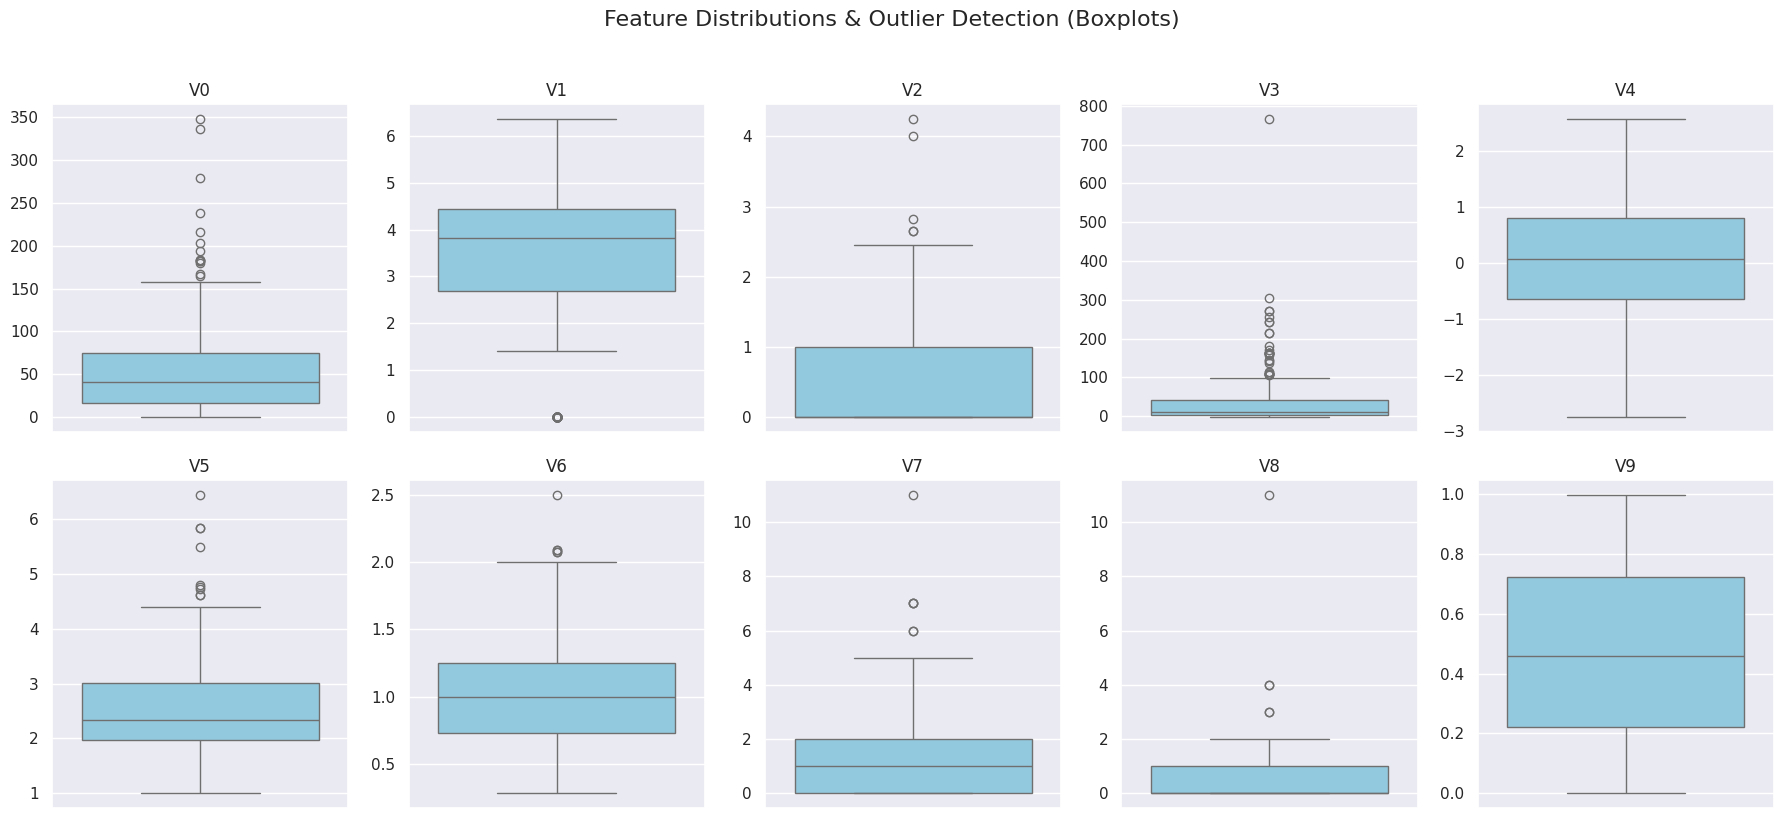

In [5]:
# Boxplots for every input feature to visualize spread and extreme values.
features_to_plot = ["V0", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9"]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 8))
fig.suptitle("Feature Distributions & Outlier Detection (Boxplots)", fontsize=16, y=1.02)
for ax, feature in zip(axes.flatten(), features_to_plot):
    sns.boxplot(y=df_raw[feature], ax=ax, color="skyblue")
    ax.set_title(feature)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

#### 2.2.2. Correlations | Correlaciones | Korrelationen

🇬🇧 **EN:** The heatmap shows the linear correlation between every pair of variables and with the target `deseada`. The strongest linear links to the target are V3, V5 and V6. One detail to keep in mind: V0 — the variable from the sensor that fails in the test set — barely correlates with the target (≈0.05). Correlation only measures *linear* relationships: a low value does not prove a variable is useless. We will come back to V0 later.

🇪🇸 **ES:** El mapa de calor muestra la correlación lineal entre cada par de variables y con el objetivo `deseada`. Los vínculos lineales más fuertes con el objetivo son V3, V5 y V6. Un detalle a tener en cuenta: V0 —la variable del sensor que falla en el conjunto de test— apenas correlaciona con el objetivo (≈0.05). La correlación solo mide relaciones *lineales*: un valor bajo no demuestra que una variable sea inútil. Volveremos a V0 más adelante.

🇩🇪 **DE:** Die Heatmap zeigt die lineare Korrelation zwischen jedem Variablenpaar und mit der Zielgröße `deseada`. Die stärksten linearen Verbindungen zur Zielgröße sind V3, V5 und V6. Ein Detail, das man im Hinterkopf behalten sollte: V0 — die Variable des Sensors, der im Testdatensatz ausfällt — korreliert kaum mit der Zielgröße (≈0,05). Korrelation misst nur *lineare* Zusammenhänge: ein niedriger Wert beweist nicht, dass eine Variable nutzlos ist. Wir kommen später auf V0 zurück.

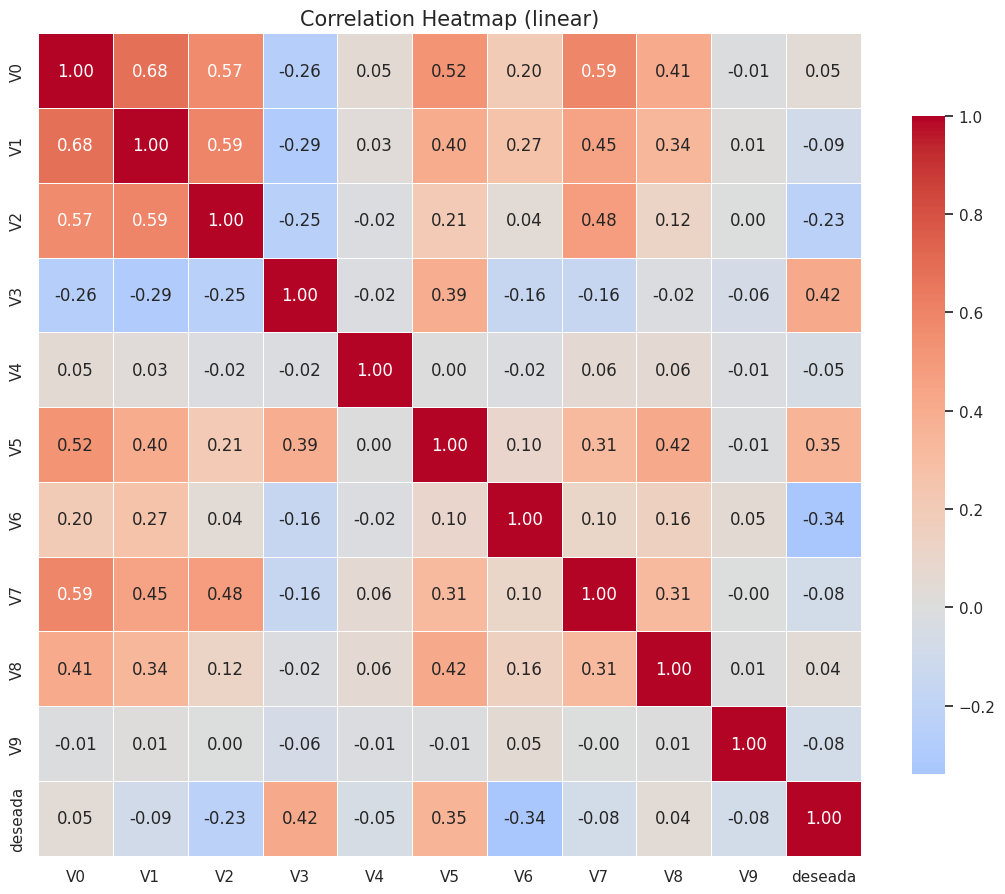

In [6]:
# Linear correlation between all variables (features + target).
corr = df_raw.corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (linear)", fontsize=15)
plt.tight_layout()
plt.show()

#### 2.2.3. Value Frequencies (V7, V8) | Frecuencias de valores (V7, V8) | Werthäufigkeiten (V7, V8)

🇬🇧 **EN:** V7 and V8 are discrete variables: most observations sit at the lowest values and large values are rare. The value 11 appears only **once** in each, skipping the values in between — a strong sign that it is an anomaly (a typo or a sensor code) rather than a normal reading.

🇪🇸 **ES:** V7 y V8 son variables discretas: la mayoría de observaciones están en los valores más bajos y los altos son raros. El valor 11 aparece una **sola vez** en cada una, saltándose los valores intermedios: una señal clara de que es una anomalía (un error de tecleo o un código del sensor) y no una lectura normal.

🇩🇪 **DE:** V7 und V8 sind diskrete Variablen: Die meisten Beobachtungen liegen bei den niedrigsten Werten, hohe Werte sind selten. Der Wert 11 kommt in jeder nur **einmal** vor und überspringt die dazwischenliegenden Werte — ein deutliches Zeichen, dass es sich um eine Anomalie handelt (ein Tippfehler oder ein Sensorcode) und nicht um eine normale Messung.

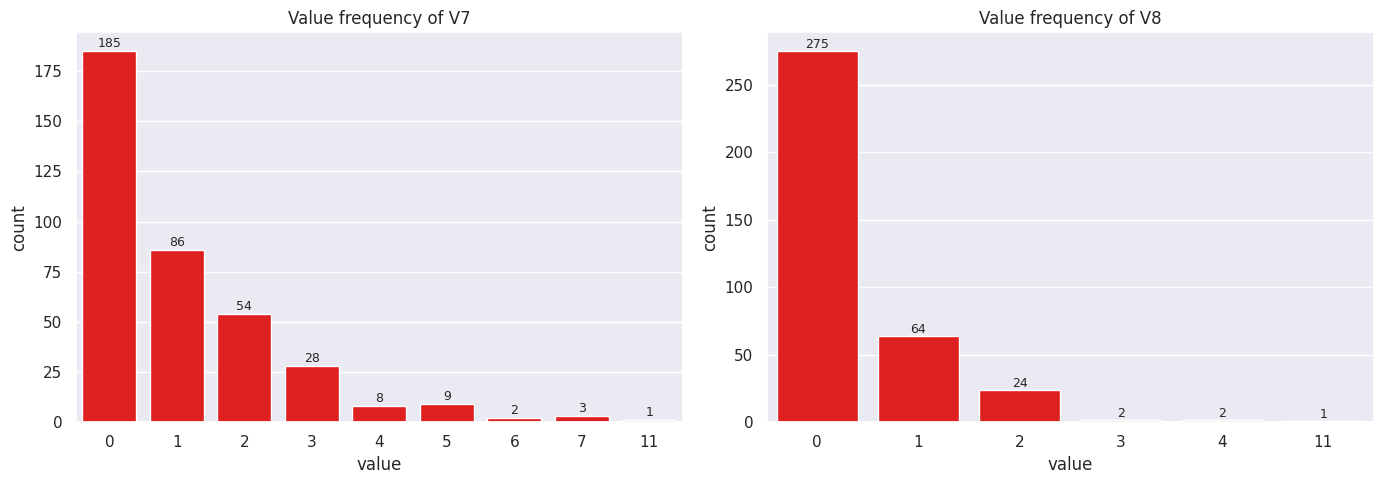

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, f in zip(axes, ["V7", "V8"]):
    counts = df_raw[f].value_counts().sort_index()
    xs = [int(i) for i in counts.index]
    sns.barplot(x=xs, y=counts.values, ax=ax, color="red")
    ax.set_title(f"Value frequency of {f}")
    ax.set_xlabel("value")
    ax.set_ylabel("count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(int(v)), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 2.3. Missing Values: Train vs Test | Nulos: Train vs Test | Fehlende Werte: Train vs Test

🇬🇧 **EN:** Real-world problems. Comparing TRAIN and TEST makes plain what Emilio warned us about in his last email. Most variables have a similar (~15%) sparse missing rate in both sets. But look at the test set: V0 — the very variable that looked irrelevant in the heatmap — disappears roughly 75% of the time. That it vanishes only in the test set is a distribution shift we have to design for.

🇪🇸 **ES:** Problemas del mundo real. Al comparar TRAIN y TEST salta a la vista lo que nos avisó Emilio en su último correo. La mayoría de variables tienen un nulo disperso similar (~15%) en ambos conjuntos. Pero si nos fijamos en el test, V0 —justo la que en el mapa de calor parecía no importar— desaparece aproximadamente el 75% del tiempo. Que desaparezca solo en el test es un cambio de distribución que tenemos que contemplar en el diseño.

🇩🇪 **DE:** Probleme aus der echten Welt. Der Vergleich von TRAIN und TEST macht deutlich, wovor uns Emilio in seiner letzten E-Mail gewarnt hat. Die meisten Variablen haben in beiden Sätzen eine ähnliche, spärliche Fehlrate (~15 %). Aber im Testsatz verschwindet V0 — genau die Variable, die in der Heatmap unwichtig schien — in etwa 75 % der Zeit. Dass sie nur im Testsatz verschwindet, ist eine Verteilungsverschiebung, die wir einplanen müssen.

In [8]:
# CRITICAL CORRECTION: compare the missing-value pattern of TRAIN vs TEST.
# This single table is what reveals the real challenge of the competition.
def missing_report(df, label):
    return pd.DataFrame({
        f"{label}_missing": df.isnull().sum(),
        f"{label}_pct": (df.isnull().mean() * 100).round(1),
    })

train_miss = missing_report(df_raw[features_to_plot], "train")
test_miss = missing_report(df_test[features_to_plot], "test")
comparison = train_miss.join(test_miss)
display(comparison)

,train_missing,train_pct,test_missing,test_pct
V0,0,0.0,82,74.5
V1,71,16.3,11,10.0
V2,63,14.4,19,17.3
V3,68,15.6,14,12.7
V4,0,0.0,0,0.0
V5,63,14.4,19,17.3
V6,70,16.1,12,10.9
V7,60,13.8,22,20.0
V8,68,15.6,14,12.7
V9,0,0.0,0,0.0


🇬🇧 **EN:** A picture makes the problem obvious. Each row is an observation and each column a variable; red marks a missing value. In TRAIN, the V0 column has no red at all: the sensor always worked. In TEST, V0 shows a continuous red band at the start: the stretch where the sensor stops working. That band is the sensor failure, and it is the heart of this competition.

🇪🇸 **ES:** Una imagen deja el problema a la vista. Cada fila es una observación y cada columna una variable; el rojo marca un valor ausente. En TRAIN, la columna V0 no tiene nada de rojo: el sensor siempre funcionó. En TEST, V0 muestra una franja roja continua al principio: el tramo donde el sensor deja de funcionar. Esa franja es la avería del sensor, y es el corazón de esta competición.

🇩🇪 **DE:** Ein Bild macht das Problem offensichtlich. Jede Zeile ist eine Beobachtung und jede Spalte eine Variable; Rot markiert einen fehlenden Wert. Im TRAIN hat die Spalte V0 überhaupt kein Rot: der Sensor funktionierte immer. Im TEST zeigt V0 ein durchgehendes rotes Band am Anfang: den Abschnitt, in dem der Sensor ausfällt. Dieses Band ist der Sensorausfall und das Herzstück dieses Wettbewerbs.

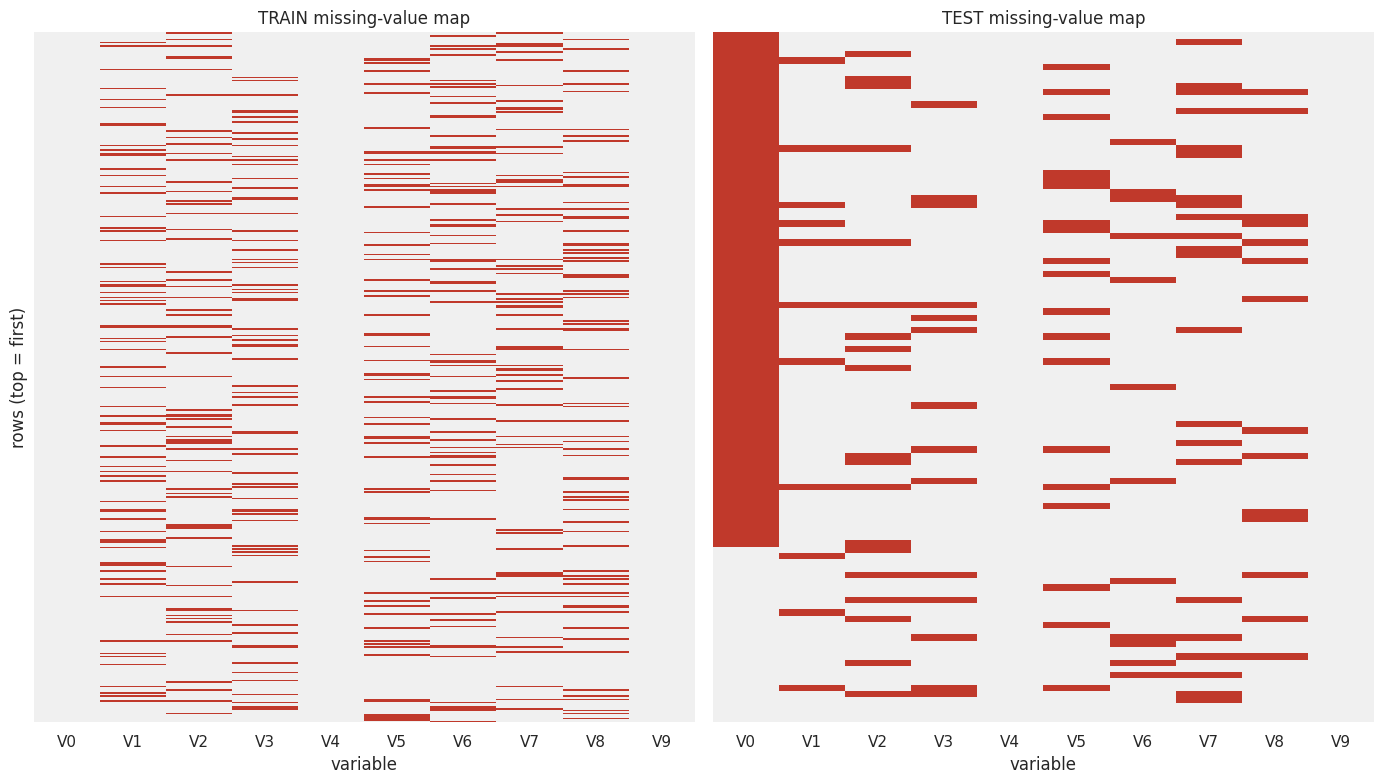

In [9]:
# Visualize the missing-value pattern, TRAIN vs TEST side by side.
# Red = missing. The long red band in the TEST V0 column IS the sensor
# outage: 82 consecutive rows with no data, exactly as the professor described.
cols = ["V0", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9"]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, (df, name) in zip(axes, [(df_raw, "TRAIN"), (df_test, "TEST")]):
    sns.heatmap(df[cols].isnull().astype(int), cmap=["#f0f0f0", "#c0392b"],
                cbar=False, yticklabels=False, ax=ax)
    ax.set_title(f"{name} missing-value map")
    ax.set_xlabel("variable")
axes[0].set_ylabel("rows (top = first)")
plt.tight_layout()
plt.show()

### 2.4. The V0 Sensor-Failure Block | El Bloque de Fallo del Sensor V0 | Der V0-Sensorausfallblock

🇬🇧 **EN:** We confirm three facts that guide every later decision:

1. V0's missing values form one **contiguous block** (the sensor outage).
2. V0 is **partially recoverable** from the other sensors (CV R² ≈ 0.77): imputing it is viable but imperfect.
3. V0 **clearly improves** the model (the MSE gets worse if we remove it).

**Conclusion:** imputing V0 blindly would inject error into one of our most important variables, so we handle it explicitly in the modeling stage.

🇪🇸 **ES:** Confirmamos tres hechos que guían todas las decisiones posteriores:

1. Los nulos de V0 forman un **bloque contiguo** (la caída del sensor).
2. V0 es **parcialmente recuperable** desde los otros sensores (R² CV ≈ 0.77): imputarlo es viable pero imperfecto.
3. V0 **mejora claramente** el modelo (el MSE empeora si lo quitamos).

**Conclusión:** imputar V0 a ciegas inyectaría error en una de nuestras variables más importantes, así que lo tratamos de forma explícita en el modelado.

🇩🇪 **DE:** Wir bestätigen drei Fakten, die alle weiteren Entscheidungen bestimmen:

1. Die fehlenden Werte von V0 bilden einen **zusammenhängenden Block** (den Sensorausfall).
2. V0 ist aus den anderen Sensoren **teilweise rekonstruierbar** (CV-R² ≈ 0,77): die Imputation ist möglich, aber unvollkommen.
3. V0 **verbessert das Modell deutlich** (der MSE verschlechtert sich, wenn wir es entfernen).

**Fazit:** V0 blind zu imputieren würde Fehler in eine unserer wichtigsten Variablen einbringen, daher behandeln wir es in der Modellierung explizit.

In [10]:
v0_mask = df_test["V0"].isnull().astype(int)
print(f"\nV0 missing in test : {df_test['V0'].isnull().sum()} / {len(df_test)} rows "
      f"({df_test['V0'].isnull().mean()*100:.0f}%)  ->  one contiguous block at the start")
print(f"V0 missing in train: {df_raw['V0'].isnull().sum()} / {len(df_raw)} rows")

# 2) Is V0 recoverable from the other sensors? (drives the imputation strategy)
cols_tmp = [c for c in features_to_plot if c != "V0"]
sub_tmp = df_raw[cols_tmp + ["V0"]].dropna()
r2_tmp = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1),
                      sub_tmp[cols_tmp], sub_tmp["V0"], cv=5, scoring="r2").mean()
print(f"\nV0 predictability from V1-V9 (CV R2): {r2_tmp:.2f}  ->  imputation is viable but imperfect")

# 3) How important is V0? CV MSE with vs without it (quick median-imputed check).
d_tmp = df_raw[features_to_plot + ["deseada"]].fillna(df_raw.median(numeric_only=True))
def mse_tmp(cols):
    return -cross_val_score(RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1),
                            d_tmp[cols], d_tmp["deseada"], cv=5, scoring="neg_mean_squared_error").mean()
print(f"CV MSE with V0   : {mse_tmp(features_to_plot):.3f}")
print(f"CV MSE without V0: {mse_tmp([c for c in features_to_plot if c != 'V0']):.3f}  ->  V0 clearly matters")


V0 missing in test : 82 / 110 rows (75%)  ->  one contiguous block at the start
V0 missing in train: 0 / 436 rows

V0 predictability from V1-V9 (CV R2): 0.77  ->  imputation is viable but imperfect
CV MSE with V0   : 1.481
CV MSE without V0: 1.856  ->  V0 clearly matters


## 3. Feature Set & Validation Philosophy | Variables y Filosofía de Validación | Merkmale & Validierungsphilosophie

🇬🇧 **EN:** We use all ten input variables (V0–V9). On validation: a standard random CV would be **misleading**, because in train V0 is always present and in the test it is missing 75% of the time, so it would measure the model in a situation that does not look like the real one. That is why we use an *honest* CV that hides V0 in 75% of the rows of each validation block (*fold*), reproducing the test condition.

🇪🇸 **ES:** Usamos las diez variables de entrada (V0–V9). Sobre la validación: una CV aleatoria normal sería **engañosa**, porque en train V0 está siempre y en el test falta el 75% de las veces, así que mediría el modelo en una situación que no se parece a la real. Por eso usamos una CV *honesta* que oculta V0 en el 75% de las filas de cada bloque de validación (*fold*), reproduciendo la condición del test.

🇩🇪 **DE:** Wir verwenden alle zehn Eingabevariablen (V0–V9). Zur Validierung: Eine herkömmliche zufällige CV wäre **irreführend**, weil V0 im Training immer vorhanden ist und im Test zu 75 % fehlt; sie würde das Modell in einer Situation messen, die der echten nicht ähnelt. Deshalb verwenden wir eine *ehrliche* CV, die V0 in 75 % der Zeilen jedes Validierungsblocks (*Fold*) verbirgt und so die Testbedingung nachbildet.

In [11]:
# Full feature set used by every model.
FEATS = ["V0", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9"]
OTHERS = [c for c in FEATS if c != "V0"]
print("Model features:", FEATS)

Model features: ['V0', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']


## 4. Modeling Architecture | Arquitectura del Modelo | Modellarchitektur

🇬🇧 **EN:** Three pieces that complement each other, all sklearn-compatible.

**(1) `TwoModelV0Regressor`** trains one model with V0 (for rows where the sensor worked) and one without V0 (fallback for the outage block), and sends each row to the model it belongs to; that way we never feed a made-up V0 into a model that relies on it. The non-V0 variables are imputed with `IterativeImputer`.

**(2) `hgb_native`** is a `HistGradientBoostingRegressor` model that handles missing values natively (it learns which way to send rows where V0 is absent) — a completely different way to attack the problem.

**(3) `BlendRegressor`** averages all three for robustness.

🇪🇸 **ES:** Tres piezas que se complementan, compatibles con sklearn.

**(1) `TwoModelV0Regressor`** entrena un modelo con V0 (para filas donde el sensor funcionó) y otro sin V0 (respaldo para el bloque de caída), y manda cada fila al modelo que le toca; así nunca metemos un V0 inventado en un modelo que se fía de él. El resto de variables se imputan con `IterativeImputer`.

**(2) `hgb_native`** es un modelo `HistGradientBoostingRegressor`, que maneja los valores ausentes de forma nativa (aprende hacia qué lado mandar las filas donde V0 falta) — una forma completamente distinta de atacar el problema.

**(3) `BlendRegressor`** promedia las tres para dar robustez.

🇩🇪 **DE:** Drei Bausteine, die sich ergänzen, alle sklearn-kompatibel.

**(1) `TwoModelV0Regressor`** trainiert ein Modell mit V0 (für Zeilen mit funktionierendem Sensor) und eines ohne V0 (Rückfalloption für den Ausfallblock) und schickt jede Zeile zum passenden Modell; so geben wir einem Modell, das sich auf V0 verlässt, nie ein erfundenes V0. Die übrigen Variablen werden mit `IterativeImputer` imputiert.

**(2) `hgb_native`** ist ein `HistGradientBoostingRegressor`-Modell, das fehlende Werte nativ verarbeitet (es lernt, in welche Richtung Zeilen ohne V0 geschickt werden) — ein völlig anderer Lösungsweg.

**(3) `BlendRegressor`** mittelt alle drei für Robustheit.

In [12]:
# === Piece 1: Two-model regressor routed by V0 availability ===========
# Trains one model WITH V0 (rows where the sensor worked) and one WITHOUT
# V0 (fallback for the sensor-failure block). Each row is routed to the
# right model, so we never feed an imputed V0 to a model that relies on it.
# Non-V0 features are imputed with IterativeImputer (MICE / BayesianRidge).
class TwoModelV0Regressor(BaseEstimator, RegressorMixin):
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        X = X[FEATS]
        self.imp_ = IterativeImputer(estimator=BayesianRidge(), random_state=0, max_iter=10)
        O = pd.DataFrame(self.imp_.fit_transform(X[OTHERS]), columns=OTHERS, index=X.index)
        full = pd.concat([X[["V0"]].reset_index(drop=True),
                          O.reset_index(drop=True)], axis=1)[FEATS]
        self.m_with_ = clone(self.base_estimator).fit(full, y)     # uses the real V0
        self.m_without_ = clone(self.base_estimator).fit(O, y)     # V0-free fallback
        return self

    def predict(self, X):
        X = X[FEATS]
        O = pd.DataFrame(self.imp_.transform(X[OTHERS]), columns=OTHERS, index=X.index)
        has_v0 = X["V0"].notna().values
        pred = np.empty(len(X))
        if has_v0.any():
            q = pd.concat([X.loc[has_v0, ["V0"]].reset_index(drop=True),
                           O.loc[has_v0].reset_index(drop=True)], axis=1)[FEATS]
            pred[has_v0] = self.m_with_.predict(q)
        if (~has_v0).any():
            pred[~has_v0] = self.m_without_.predict(O.loc[~has_v0])
        return pred


# === Piece 2: Native-NaN model ========================================
# HistGradientBoosting handles NaN natively (it learns the best branch for
# missing values), so it needs no imputation. It attacks the problem in a
# completely different way from Piece 1 -> adds diversity to the blend.
hgb_native = HistGradientBoostingRegressor(random_state=42, max_iter=500,
                                           learning_rate=0.05, max_depth=3,
                                           l2_regularization=1.0, min_samples_leaf=20)


# === Piece 3: Blend of three diverse models ===========================
class BlendRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, estimators):
        self.estimators = estimators

    def fit(self, X, y):
        self.fitted_ = [clone(est).fit(X, y) for _, est in self.estimators]
        return self

    def predict(self, X):
        return np.mean([m.predict(X) for m in self.fitted_], axis=0)


def make_model():
    return BlendRegressor([
        ("tm_rf",  TwoModelV0Regressor(RandomForestRegressor(
                        n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1))),
        ("tm_hgb", TwoModelV0Regressor(HistGradientBoostingRegressor(
                        random_state=42, max_iter=500, learning_rate=0.05, max_depth=3,
                        l2_regularization=1.0, min_samples_leaf=20))),
        ("native", clone(hgb_native)),
    ])

print("Architecture defined: TwoModelV0Regressor + hgb_native + BlendRegressor")

Architecture defined: TwoModelV0Regressor + hgb_native + BlendRegressor


### 4.1. Outlier decision | Decisión sobre los valores extremos | Entscheidung zu den Ausreißern

🇬🇧 **EN:** Now that we are going to use tree-based models, we can settle the decision about the extreme values we saw earlier. We keep them as they are, without removing or clipping them, for three reasons: the dataset is small and every row is an example the model needs; tree models are robust to extreme values, because they decide based on the order of the values, not their size; and since the competition is scored with MSE, which heavily penalizes large errors, we want the model to see the full range of the data —including the extreme cases— so it doesn't fail on them.

🇪🇸 **ES:** Ahora que vamos a usar modelos de árbol, podemos cerrar la decisión sobre los valores extremos que vimos antes. Los dejamos tal cual, sin eliminarlos ni recortarlos, por tres motivos: el dataset es pequeño y cada fila es un ejemplo que el modelo necesita; los árboles son robustos a los valores extremos, porque deciden por el orden de los valores y no por su tamaño; y como la competición se puntúa con el MSE, que penaliza mucho los errores grandes, nos interesa que el modelo vea el rango completo de los datos —incluidos los casos extremos— para no fallar en ellos.

🇩🇪 **DE:** Jetzt, da wir baumbasierte Modelle verwenden, können wir die Entscheidung über die Extremwerte treffen, die wir zuvor gesehen haben. Wir behalten sie unverändert, ohne sie zu entfernen oder zu beschneiden, aus drei Gründen: Der Datensatz ist klein und jede Zeile ist ein Beispiel, das das Modell braucht; Baummodelle sind robust gegenüber Extremwerten, weil sie nach der Reihenfolge der Werte entscheiden und nicht nach ihrer Größe; und da der Wettbewerb mit dem MSE bewertet wird, der große Fehler stark bestraft, möchten wir, dass das Modell den gesamten Wertebereich sieht —einschließlich der Extremfälle—, damit es bei ihnen nicht versagt.

## 5. Honest Cross-Validation | Validación Cruzada Honesta | Ehrliche Kreuzvalidierung

🇬🇧 **EN:** We mask V0 in ~74.5% of every validation fold (matching the 82/110 ratio of the test) and measure MSE. This is the number we should actually expect on the leaderboard — far more honest than a CV where V0 is always present.

🇪🇸 **ES:** Enmascaramos V0 en ~74.5% de cada fold de validación (igual que la proporción 82/110 del test) y medimos el MSE. Este es el número que de verdad deberíamos esperar en el ranking — mucho más honesto que una CV donde V0 siempre está presente.

🇩🇪 **DE:** Wir maskieren V0 in ~74,5 % jedes Validierungs-Folds (entsprechend dem Verhältnis 82/110 des Tests) und messen den MSE. Dies ist der Wert, den wir tatsächlich in der Rangliste erwarten sollten — weitaus ehrlicher als eine CV, in der V0 immer vorhanden ist.

In [13]:
# Honest validation: standard CV is misleading here because TRAIN never has
# a missing V0, while 75% of TEST does. We replicate the test condition by
# masking V0 in ~74.5% of every validation fold.
X_train = df_raw[FEATS].copy()
y_train = df_raw["deseada"].values
V0_MISS_RATE = 0.745  # matches the test set (82 / 110)

def honest_cv(X, y, rate=V0_MISS_RATE, seeds=3):
    scores = []
    for s in range(seeds):
        for tr_idx, va_idx in KFold(5, shuffle=True, random_state=s).split(X):
            X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
            y_tr, y_va = y[tr_idx], y[va_idx]
            rng = np.random.RandomState(s * 100 + len(va_idx))
            mask = rng.rand(len(X_va)) < rate
            X_va.loc[X_va.index[mask], "V0"] = np.nan       # simulate sensor failure
            preds = make_model().fit(X_tr, y_tr).predict(X_va)
            scores.append(mean_squared_error(y_va, preds))
    return np.array(scores)

cv_scores = honest_cv(X_train, y_train)
print(f"HONEST CV MSE (V0 missing 74.5% of rows): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

HONEST CV MSE (V0 missing 74.5% of rows): 1.6597 +/- 0.2904


## 6. Final Prediction & Export | Predicción Final y Exportación | Finale Vorhersage & Export

🇬🇧 **EN:** We fit the blend on 100% of the training data, predict the blind test, and export a single-column file named with the candidate's surname, as the professor requested. **Note:** confirm whether he wants a literal `.xls` and whether the column should keep its header.

🇪🇸 **ES:** Ajustamos el blend con el 100% de los datos de entrenamiento, predecimos el test ciego y exportamos un archivo de una sola columna nombrado con el apellido del candidato, como pidió el profesor. **Nota:** confirmar si quiere un `.xls` literal y si la columna debe conservar la cabecera.

🇩🇪 **DE:** Wir trainieren das Blend mit 100 % der Trainingsdaten, sagen den Blindtest voraus und exportieren eine einspaltige Datei, die nach dem Nachnamen des Kandidaten benannt ist, wie vom Professor gewünscht. **Hinweis:** klären, ob er ein wörtliches `.xls` möchte und ob die Spalte ihre Kopfzeile behalten soll.

In [14]:
# Fit the final blend on 100% of the training data and predict the blind test.
final_model = make_model().fit(X_train, y_train)
final_predictions = final_model.predict(df_test[FEATS])

print(f"Predictions: n={len(final_predictions)} | "
      f"range=[{final_predictions.min():.3f}, {final_predictions.max():.3f}] | "
      f"mean={final_predictions.mean():.3f} | std={final_predictions.std():.3f}")

# Export format requested by the professor: a single column named with the
# candidate's surname. Confirm .xls vs .xlsx and header preference with him.
output = pd.DataFrame({"deseada": final_predictions})
file_name = f"Predicciones_Riquelme_Riquelme.xlsx"
output.to_excel(file_name, index=False)
print(f"File saved: {file_name}")

Predictions: n=110 | range=[1.303, 7.548] | mean=4.454 | std=1.167
File saved: Predicciones_Riquelme_Riquelme.xlsx


## 7. Sanity Check & Conclusions | Verificación y Conclusiones | Plausibilitätsprüfung & Fazit

🇬🇧 **EN:** We re-read the exported file to verify shape, columns, and absence of NaNs. We also compare the prediction spread against the training target: less standard-deviation compression means the model is less regressed to the mean than a naive imputation pipeline would be — a good sign for MSE on the extreme rows.

🇪🇸 **ES:** Releemos el archivo exportado para verificar forma, columnas y ausencia de NaNs. También comparamos la dispersión de las predicciones con la del objetivo de entrenamiento: menos compresión de la desviación típica significa que el modelo está menos regresado a la media que una imputación ingenua — buena señal para el MSE en las filas extremas.

🇩🇪 **DE:** Wir lesen die exportierte Datei erneut ein, um Form, Spalten und das Fehlen von NaNs zu prüfen. Außerdem vergleichen wir die Streuung der Vorhersagen mit der Zielgröße im Training: weniger Standardabweichungskompression bedeutet, dass das Modell weniger zum Mittelwert regrediert als eine naive Imputation — ein gutes Zeichen für den MSE bei den extremen Zeilen.

In [15]:
# Final sanity check on the exported file.
check = pd.read_excel(file_name)
print(f"Rows    : {len(check)} (expected 110)")
print(f"Columns : {list(check.columns)} (expected ['deseada'])")
print(f"NaNs    : {check['deseada'].isna().sum()} (expected 0)")
print(f"Range   : [{check['deseada'].min():.3f}, {check['deseada'].max():.3f}]")
print(f"Pred std: {check['deseada'].std():.3f}  vs  train target std: {df_raw['deseada'].std():.3f}")
print("\nLess std compression than the original notebook -> predictions less regressed to the mean.")

Rows    : 110 (expected 110)
Columns : ['deseada'] (expected ['deseada'])
NaNs    : 0 (expected 0)
Range   : [1.303, 7.548]
Pred std: 1.172  vs  train target std: 1.663

Less std compression than the original notebook -> predictions less regressed to the mean.
